In [3]:
using CSVFiles

In [4]:
using LinearAlgebra
using DataFrames
using DataFrames
using Measurements
import Measurements: value, uncertainty

In [5]:
##alles was hier kommt sind nur rundungsfunktionen und eine voreinstellung für die Achsenbeschriftung


using CSV
using CSVFiles
using CairoMakie

using DataFrames
using Measurements
import Measurements: value, uncertainty
using Statistics



using Random, Statistics

function first_significant_digit(x::Real)
    x == 0 && return 0  # Sonderfall: Wenn x genau 0 ist, gibt es keine signifikante Stelle, also gib 0 zurück.

    absx = abs(x)  # Der Betrag der Zahl wird genommen, damit negative Vorzeichen ignoriert werden.

    # Berechne die Zehnerpotenz, in der sich die erste signifikante Stelle befindet.
    # log10(absx) gibt den dekadischen Logarithmus. floor(Int, ...) rundet nach unten auf ganze Zahl.
    exponent = floor(Int, log10(absx))

    # Teile absx durch 10^exponent, um die Zahl in den Bereich [1,10) zu bringen
    # Beispiel: aus 456 → 4.56, aus 0.00456 → 4.56
    significand = absx / 10.0^exponent

    # Jetzt holen wir die ganzzahlige Ziffer vor dem Komma, das ist die erste signifikante Ziffer
    return floor(Int, significand)
end


"""
    round_measurement(m::Measurement; sigdigits_error::Int=1)

Rundet erst die Unsicherheit von `m` auf `sigdigits_error` signifikante Stellen
und rundet dann den Messwert auf dieselbe Genauigkeit (Dezimalstellen),
liefert einen neuen `Measurement`. Sigdigits_error wird automatisch auf den richtigen wert gesetzt durch if bedingung 
wenn first sig digit =1 oder 2, wird eine weitere stelle hinzugenommen.

input: ein measurement, output: ein measurement. Kann punktweise angewendet werden
"""
function round_measurement(m::Measurement)
    # 1) Unsicherheit extrahieren und auf sigdigits_error sig. Stellen runden
    u = uncertainty(m)
    if first_significant_digit(u)<3
        sigdigits_error=2
    else
        sigdigits_error=1
    end
    #println(sigdigits_error)

    u_r = round(u; sigdigits=sigdigits_error)

    
    if u_r==0 #wenn gauß versagt, normalverteilung und stw
        

    # Ziehe N Stichproben aus einer Normalverteilung und berechne KINETISCHE ENERGIE!!!
    p_samples = randn(100_000) .* 0.05  # p ~ N(0, σp=0.05) kein plan warum, aber die 0.05 sind auf jkeden fall der fehler vorher

    # Berechne kinetische Energie für jede Probe
    E_samples = p_samples.^2 ./ (2)

    # Mittelwert und Standardabweichung der Energie
    E_mean = mean(E_samples)
    E_std = std(E_samples)
    
    u_r = round(E_std; sigdigits=sigdigits_error)
        #println(u_r)
    end
    
    
    
    
    
    # 2) Anzahl Dezimalstellen bestimmen:
    #    Wenn u_r = x * 10^e  (mit 1 ≤ x < 10), dann ist e = floor(log10(u_r))
    #    und wir benötigen -e  Dezimalstellen (für e ≤ 0)
    e = floor(Int, log10(u_r))
       # println(e)
    if first_significant_digit(u)<3
        dec = max(0, -e) +1
    else
        dec = max(0, -e)
    end
    #dec = max(0, -e)
    #println(dec, log(12,u_r))

    # 3) Wert runden und neuen Measurement erstellen
    v_r = round(value(m); digits=dec)
    return measurement(v_r, u_r)
end

# Beispiel
m = measurement(0.023456, 0.0120236789)
println("Original: ", value(m))                  # 1.23456 ± 0.06789
m2 = round_measurement(m)
println("Gerundet: ", value(m2))  # z.B. 1.23(7) → ±0.07, Wert 1.23



#Skalierung der x-Achse ##ANPASSEN##
yticks = 0:0.025:01.2
yticklabels = [i*100 % 1 == 0 ? string(i) : " " for i in yticks]
#Skalierung der y-Achse ##ANPASSEN##
xticks = 0:1:50
xticklabels = [j % 5 == 0 ? string(j) : " " for j in xticks];

x = value.(x_M)##ANPASSEN##
y = value.(R_M) ##ANPASSEN##
#Fehler-Array mit gleichem Fehler
Δx= uncertainty.(x_M)
Δy= uncertainty.(R_M)   
#=for i in 1:length(x)
    push!(Δx,ΔV) ###ANPASSEN##
    push!(Δy,ΔT) ##ANPASSEN##
end=#

with_theme(theme_latexfonts()) do
    fig = Figure()
    ax = Axis(fig[1,1])
    #Fehlerbalken
    errorbars!(ax, x, y, Δy, color=:grey, whiskerwidth = 5)
    errorbars!(ax, x, y, Δx, color=:grey, whiskerwidth = 5, direction = :x)
    #Messwerte
    scatter!(ax,x, y, markersize = 6, color=:black)

    ax.title = L"$R_M(x)$" ##ANPASSEN##
    ax.ylabel = L" $R~in~[\Omega /cm]$" ##ANPASSEN##
    ax.xlabel = L"  x~in~[cm]" ##ANPASSEN##

    ax.xticks = (xticks, xticklabels)
    ax.yticks = (yticks, yticklabels) 
    #plot speichern
    save("RM(x).png", fig, px_per_unit = 2) ##ANPASSEN##

    fig
end

Original: 0.023456
Gerundet: 0.023


LoadError: UndefVarError: `x_M` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [8]:

function generate_reflections(hmax,nth)
    sc  = Dict{Int, Vector{Tuple{Int,Int,Int}}}()
    bcc = Dict{Int, Vector{Tuple{Int,Int,Int}}}()
    fcc = Dict{Int, Vector{Tuple{Int,Int,Int}}}()

    for h in 0:hmax, k in 0:hmax, l in 0:hmax
        if h == 0 && k == 0 && l == 0
            continue
        else
        N = h^2 + k^2 + l^2
        hkl = (h,k,l)

        # --- SC: alle erlaubten Reflexe ---
        if length(sc) == nth
            if N < maximum(keys(sc))
                delete!(sc, maximum(keys(sc)))
            end
        end 

        if length(fcc) == nth
            if N < maximum(keys(fcc))
                delete!(fcc, maximum(keys(fcc)))
            end
        end 

        if length(bcc) == nth
            if N < maximum(keys(bcc))
                delete!(bcc, maximum(keys(bcc)))
            end
        end 


        if length(sc) < nth
            push!(get!(sc, N, Vector{Tuple{Int,Int,Int}}()), hkl)
        end

        # --- BCC: h+k+l gerade ---
        if length(bcc) < nth
            if (h + k + l) % 2 == 0
                push!(get!(bcc, N, Vector{Tuple{Int,Int,Int}}()), hkl) 
            end
        end

        # --- FCC: alle h,k,l entweder alle gerade oder alle ungerade ---
        if length(fcc) < nth
            if (h % 2 == k % 2 == l % 2)
                push!(get!(fcc, N, Vector{Tuple{Int,Int,Int}}()), hkl)
            end
        end
    end
    end
    sc_sorted = [(N, sc[N]) for N in sort(collect(keys(sc)))]
    bcc_sorted = [(N, bcc[N]) for N in sort(collect(keys(bcc)))]
    fcc_sorted = [(N, fcc[N]) for N in sort(collect(keys(fcc)))]
    return sc_sorted, bcc_sorted, fcc_sorted
end


generate_reflections (generic function with 1 method)

In [9]:
sc,bcc,fcc = generate_reflections(5,3)


([(1, [(0, 0, 1), (0, 1, 0), (1, 0, 0)]), (2, [(0, 1, 1), (1, 0, 1), (1, 1, 0)]), (3, [(1, 1, 1)])], [(2, [(0, 1, 1), (1, 0, 1), (1, 1, 0)]), (4, [(0, 0, 2), (0, 2, 0), (2, 0, 0)]), (6, [(2, 1, 1)])], [(3, [(1, 1, 1)]), (4, [(0, 0, 2), (0, 2, 0), (2, 0, 0)]), (8, [(2, 2, 0)])])

In [10]:
sc_sorted = [(N, sc[N]) for N in sort(collect(keys(sc)))]
bcc_sorted = [(N, bcc[N]) for N in sort(collect(keys(bcc)))]
fcc_sorted = [(N, fcc[N]) for N in sort(collect(keys(fcc)))]

3-element Vector{Tuple{Int64, Tuple{Int64, Vector{Tuple{Int64, Int64, Int64}}}}}:
 (1, (3, [(1, 1, 1)]))
 (2, (4, [(0, 0, 2), (0, 2, 0), (2, 0, 0)]))
 (3, (8, [(2, 2, 0)]))

In [11]:
function table(th)
    row1 = round_measurement.(th ./2)
    row2 = round_measurement.(sin.((th ./2).*pi ./180))
    sc, bcc, fcc = generate_reflections(5, length(th))
    row3 = []
    row4 = []
    row5 = []
    row6 = []
    row7 = []
    row8 = []
    for i in 1:min(length(sc), length(bcc), length(fcc))
        push!(row3, sc[i][2][1])
        push!(row4, round(sqrt(sc[i][1]), sigdigits=3))

        push!(row5, bcc[i][2][1])
        push!(row6, round(sqrt(bcc[i][1]), sigdigits=3))
        
        push!(row7, fcc[i][2][1])
        push!(row8, round(sqrt(fcc[i][1]), sigdigits=3))
    end
    DataFrame(θ=row1, sinθ=row2, sc=row3, sqrtsc=row4, bcc=row5, sqrtbcc=row6, fcc=row7, sqrtfcc=row8)
end


table (generic function with 1 method)

In [12]:
t=table(measurement.([0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360],0.1))
#(th = t[:,2])
#(root = t[:,8])
delth = 0


0

In [13]:
function nice_ticks_and_labels(x; n_ticks=20, n_labels=21, sigdigit=8)
    order = Float64(floor(Int, log10(maximum(x))))
    n = Float64(floor(Int, maximum(x) / 10^order))+1  # erste Ziffer
    tick_max = n * 10^order

    # Tick-Positionen: 0, 1*10^order, 2*10^order, ..., n*10^order
    ticks = round.(collect((0:100/n_ticks*10^(order-2):tick_max)) ; digits =sigdigit)  # feinere Tick-Striche

    # Beschriftete Zahlen: 10 gleichmäßig
    labels = collect(range(0, stop=tick_max, length=n_labels))

    return ticks, labels
end

function alignedlabels(ticks, labels; atol=0.01)
    aligned = String[]
    for x in ticks
        match = findfirst(lbl -> isapprox(x, lbl; atol=atol, rtol=0), labels)
        if match === nothing
            push!(aligned, "")
        else
            push!(aligned, string(labels[match]))
        end
    end
    return aligned
end






x = value.(th)##ANPASSEN##
y = root ##ANPASSEN##
#Fehler-Array mit gleichem Fehler
Δx= delth
Δy= 0   
#=for i in 1:length(x)
    push!(Δx,ΔV) ###ANPASSEN##
    push!(Δy,ΔT) ##ANPASSEN##
end=#
#=for i in 1:length(x)
    push!(Δx,ΔV) ###ANPASSEN##
    push!(Δy,ΔT) ##ANPASSEN##
end=#

with_theme(theme_latexfonts()) do
    fig = Figure()
    ax = Axis(fig[1,1])
    #Fehlerbalken
    #errorbars!(ax, x, y, Δy, color=:grey, whiskerwidth = 5)
    errorbars!(ax, x, y, Δx, color=:grey, whiskerwidth = 5, direction = :x)
    #Messwerte
    scatter!(ax,x, y, markersize = 6, color=:black)
    
    ax.title = L"$Geradenanpassung$" ##ANPASSEN##


    #Skalierung der x-Achse ##ANPASSEN##
xticks = nice_ticks_and_labels(x, n_labels=21, n_ticks=40)[1]
xticklabels = nice_ticks_and_labels(x, n_labels=21, n_ticks=40)[2]
aligned_xlabels = alignedlabels(xticks, xticklabels)
#Skalierung der y-Achse ##ANPASSEN##
yticks = nice_ticks_and_labels(y, n_labels=21)[1]
yticklabels = nice_ticks_and_labels(y, n_labels=21)[2]   
aligned_ylabels = alignedlabels(yticks, yticklabels)
ax.xlabel = L" $sin(\theta)$" ##ANPASSEN##
ax.ylabel = L"$\sqrt(h^2 +k^2 +l^2)$  " ##ANPASSEN##

ax.xticks = (xticks, aligned_xlabels)
ax.yticks = (yticks, aligned_ylabels) 

#axislegend(ax; position=(:left, :top))
    #plot speichern
    #save("Messung_E_A.png", fig, px_per_unit = 2) ##ANPASSEN##

    fig
end

LoadError: UndefVarError: `th` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
using CSV


In [14]:
messung = (DataFrame(load("C:/Users/va/Uni/Praktikum/Praktikum_B/Festkörperphysik/Röntgennografische_Methoden/Fittergebnisse_CSV/Probe_1_Gewichteter_Mittelwert.csv")))

Row,Peak_Label,Weighted_Mean_Theta,Error_Weighted_Mean_Theta
,Float64,Float64,Float64
1,27.91,13.9478,0.00264407
2,32.25,16.0989,0.00177338
3,43.72,21.8882,0.011669
4,45.89,22.9601,0.000434327
5,54.27,27.159,0.0170751
6,56.96,28.4624,0.0010814
7,66.64,33.3286,0.0048203
8,75.69,37.8571,0.00381102
9,84.33,42.1894,0.00302309


In [15]:

Probe_1 = measurement.(messung[:,1], messung[:,3].*2)


12-element Vector{Measurement{Float64}}:
  27.91 ± 0.0053
  32.25 ± 0.0035
  43.72 ± 0.023
  45.89 ± 0.00087
  54.27 ± 0.034
  56.96 ± 0.0022
  66.64 ± 0.0096
  75.69 ± 0.0076
  84.33 ± 0.006
 101.42 ± 0.01
 110.26 ± 0.013
 119.66 ± 0.0062

In [16]:
werte= table(Probe_1)
th1 = werte[:,2]
sc  = werte[:,4]
bcc = werte[:,6]
fcc = werte[:,8]
save("Wertetabelle.csv", werte)
werte
print(value.(th1))
th1 = [0.24116, 0.277734, 0.389847, 0.45609, 0.476852, 0.54931, sin(36.5/180*pi), 0.61353, 0.67127,sin(45/180*pi), 0.77395, sin(53/180*pi)]
fcc

[0.24116, 0.277734, 0.37234, 0.389847, 0.45609, 0.476852, 0.54931, 0.61353, 0.67127, 0.77395, 0.82045, 0.864538]

12-element Vector{Any}:
 1.73
 2.0
 2.83
 3.32
 3.46
 4.0
 4.36
 4.47
 4.9
 5.2
 5.66
 5.92

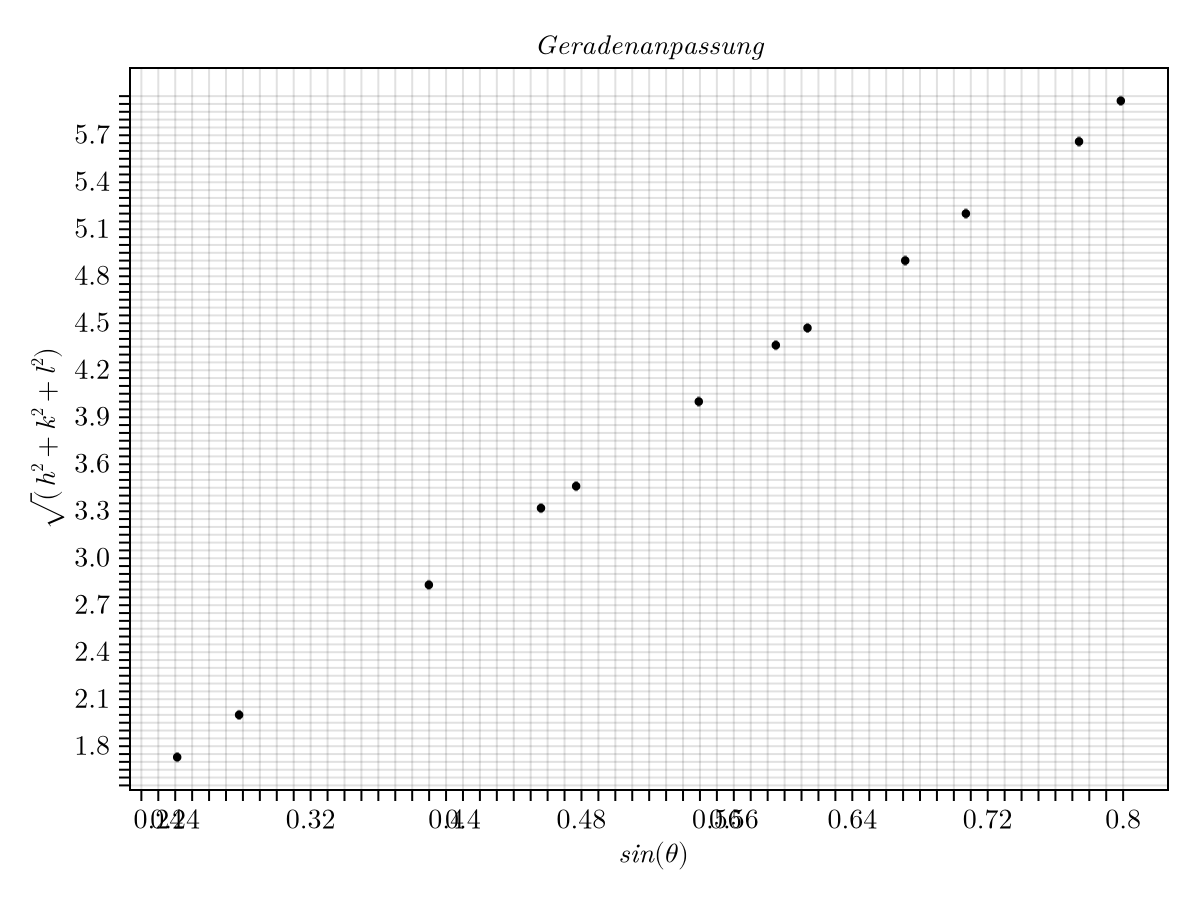

In [20]:
x = th1
#x = value.(th1)##ANPASSEN##
y = fcc ##ANPASSEN##
#Fehler-Array mit gleichem Fehler
Δx= delth
Δy= 0   
#=for i in 1:length(x)
    push!(Δx,ΔV) ###ANPASSEN##
    push!(Δy,ΔT) ##ANPASSEN##
end=#
#=for i in 1:length(x)
    push!(Δx,ΔV) ###ANPASSEN##
    push!(Δy,ΔT) ##ANPASSEN##
end=#

with_theme(theme_latexfonts()) do
    fig = Figure()
    ax = Axis(fig[1,1])
    #Fehlerbalken
    #errorbars!(ax, x, y, Δy, color=:grey, whiskerwidth = 5)
    errorbars!(ax, x, y, Δx, color=:grey, whiskerwidth = 5, direction = :x)
    #Messwerte
    scatter!(ax,x, y, markersize = 6, color=:black)
    
    ax.title = L"$Geradenanpassung$" ##ANPASSEN##


    #Skalierung der x-Achse ##ANPASSEN##
xticks = nice_ticks_and_labels(x, n_labels=11, n_ticks=10)[1]
xticklabels = nice_ticks_and_labels(x, n_labels=11, n_ticks=40)[2]
aligned_xlabels = alignedlabels(xticks, xticklabels)
#Skalierung der y-Achse ##ANPASSEN##
yticks = nice_ticks_and_labels(y, n_labels=21)[1]
yticklabels = nice_ticks_and_labels(y, n_labels=21)[2]   
aligned_ylabels = alignedlabels(yticks, yticklabels)
ax.xlabel = L" $sin(\theta)$" ##ANPASSEN##
ax.ylabel = L"$\sqrt(h^2 +k^2 +l^2)$  " ##ANPASSEN##

ax.xticks = (xticks, aligned_xlabels)
ax.yticks = (yticks, aligned_ylabels) 

#axislegend(ax; position=(:left, :top))
    #plot speichern
    save("Messung_Probe1_bcc.png", fig, px_per_unit = 2) ##ANPASSEN##

    fig
end

In [55]:
x, y, z =(generate_reflections(10,10))

DataFrame(x=x, y=y, z=z)

Row,x,y,z
,Tuple…,Tuple…,Tuple…
1,"(0, [(0, 0, 0)])","(0, [(0, 0, 0)])","(0, [(0, 0, 0)])"
2,"(1, [(0, 0, 1), (0, 1, 0), (1, 0, 0)])","(2, [(0, 1, 1), (1, 0, 1), (1, 1, 0)])","(3, [(1, 1, 1)])"
3,"(2, [(0, 1, 1), (1, 0, 1), (1, 1, 0)])","(4, [(0, 0, 2), (0, 2, 0), (2, 0, 0)])","(4, [(0, 0, 2), (0, 2, 0), (2, 0, 0)])"
4,"(3, [(1, 1, 1)])","(6, [(1, 1, 2), (1, 2, 1), (2, 1, 1)])","(8, [(0, 2, 2), (2, 0, 2), (2, 2, 0)])"
5,"(4, [(0, 0, 2), (0, 2, 0), (2, 0, 0)])","(8, [(0, 2, 2), (2, 0, 2), (2, 2, 0)])","(11, [(1, 1, 3), (1, 3, 1), (3, 1, 1)])"
6,"(5, [(0, 1, 2), (0, 2, 1), (1, 0, 2), (1, 2, 0), (2, 0, 1), (2, 1, 0)])","(10, [(0, 1, 3), (0, 3, 1), (1, 0, 3), (1, 3, 0), (3, 0, 1), (3, 1, 0)])","(12, [(2, 2, 2)])"
7,"(6, [(1, 1, 2), (1, 2, 1), (2, 1, 1)])","(12, [(2, 2, 2)])","(16, [(0, 0, 4), (0, 4, 0), (4, 0, 0)])"
8,"(8, [(0, 2, 2), (2, 0, 2), (2, 2, 0)])","(14, [(1, 2, 3), (1, 3, 2), (2, 1, 3), (2, 3, 1), (3, 1, 2), (3, 2, 1)])","(19, [(1, 3, 3), (3, 1, 3), (3, 3, 1)])"
9,"(9, [(0, 0, 3), (0, 3, 0), (1, 2, 2), (2, 1, 2), (2, 2, 1), (3, 0, 0)])","(16, [(0, 0, 4), (0, 4, 0), (4, 0, 0)])","(20, [(0, 2, 4), (0, 4, 2), (2, 0, 4), (2, 4, 0), (4, 0, 2), (4, 2, 0)])"
